# 📊 Topic 2: Measures of Dispersion — Measuring Spread, Risk, and Uncertainty
**Course**: CMPS 360 / Data Analytics  
**Context**: Qatar Real-World Applications (Logistics Delivery Times, Supply Chain Commitments)  
**Lecture Reference**: Chapter 3: Statistics for Data Insights (Slides 25–32)

---

## 🎯 Learning Objectives
By the end of this demo, you will be able to:
1. Explain why **center alone is never enough** ("Same Mean, Completely Different Risk").
2. Compute and interpret the **Range**, **Variance ($s^2$)**, and **Standard Deviation ($s$)**.
3. Calculate **Percentiles**, **Quartiles ($Q_1, Q_2, Q_3$)**, and the **Interquartile Range ($IQR$)**.
4. Test and visualize the **68–95–99.7 Empirical Rule** on normal data.
5. Standardize variables into **$z$-Scores** ($z = (x - \bar{x})/s$) to identify unusual observations.
6. Use the unitless **Coefficient of Variation ($CV = s/\bar{x}$)** to compare consistency across columns measured in different units.
7. Understand why **customer commitments and SLAs live in the tails** ($p_{95}, p_{99}$), not in the average.

---

## 🇶🇦 Qatar Real-World Scenario
In Qatar's fast-growing e-commerce and logistics sector, companies deliver packages across Doha, Lusail, Al Wakrah, and Al Rayyan.  
We examine `data/delivery_times.csv`:
* Two delivery options: **Express Delivery** vs. **Standard Delivery**.
* Both options have an identical mean delivery time of **50.0 minutes**!
* However, one option is tightly predictable, while the other fluctuates wildly.


In [14]:
# Step 0: Import analytical and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Why Spread Matters: Same Centre, Completely Different Risk

As emphasized in **Lecture Slide 26**:
> *"Dispersion tells you how much the centre can be trusted — how wrong that one number is allowed to be."*

Consider two Qatar delivery fleets:
* **Fleet A (Express)**: Deliveries cluster closely around 50 minutes.
* **Fleet B (Standard)**: Deliveries range from 15 minutes to over 90 minutes.

If a manager only looks at the mean (50 min), they might mistakenly conclude both services perform identically!


In [15]:
# Step 1: Load Qatar delivery logistics dataset
df_delivery = pd.read_csv('data/delivery_times.csv')

# Inspect the two fleets
print("=== Dataset Sample (data/delivery_times.csv) ===")
print(df_delivery[['order_id', 'service_type', 'delivery_time_minutes', 'package_weight_kg', 'shipping_fee_qar']].head())


=== Dataset Sample (data/delivery_times.csv) ===
  order_id      service_type  delivery_time_minutes  package_weight_kg  \
0  DEL-001  Express Delivery                   60.3               8.49   
1  DEL-002  Express Delivery                   52.4               6.21   
2  DEL-003  Express Delivery                   53.5              11.72   
3  DEL-004  Express Delivery                   51.9               2.84   
4  DEL-005  Express Delivery                   52.5               3.94   

   shipping_fee_qar  
0             58.20  
1             47.94  
2             72.74  
3             32.78  
4             37.73  


In [16]:
# Step 2: Compare the Mean of both services
mean_summary = df_delivery.groupby('service_type')['delivery_time_minutes'].mean().reset_index()
print("=== Mean Delivery Time by Service ===")
print(mean_summary.round(1))


=== Mean Delivery Time by Service ===
        service_type  delivery_time_minutes
0   Express Delivery                   51.6
1  Standard Delivery                   54.4


C:\Users\erradi\AppData\Local\Temp\ipykernel_7196\2891716545.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


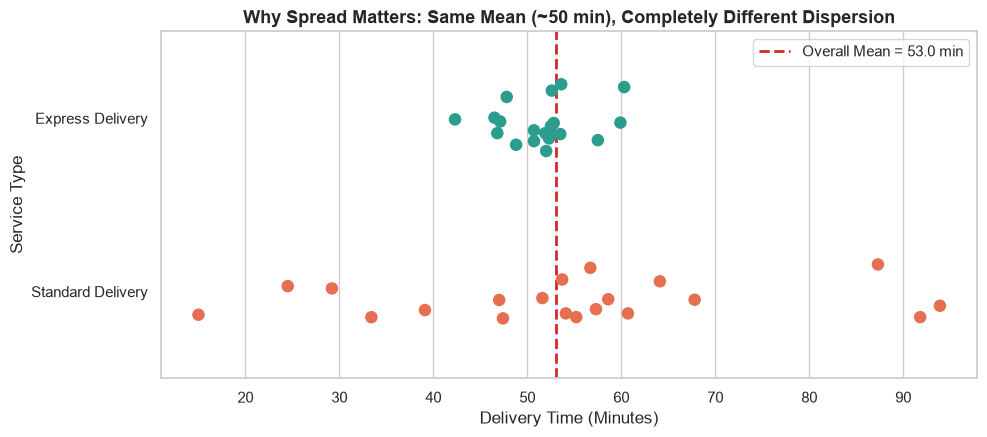

In [17]:
# Step 3: Visualize the spread: Same Mean, Starkly Different Risk (Slide 26)
fig, ax = plt.subplots(figsize=(10, 4.5))

sns.stripplot(
    data=df_delivery,
    x='delivery_time_minutes',
    y='service_type',
    jitter=0.2,
    size=9,
    palette=['#2a9d8f', '#e76f51'],
    ax=ax
)

# Draw vertical dashed line at the common mean (50.0 min)
common_mean = df_delivery['delivery_time_minutes'].mean()
ax.axvline(common_mean, color='#d62728', linestyle='--', linewidth=2, label=f'Overall Mean = {common_mean:.1f} min')

ax.set_title("Why Spread Matters: Same Mean (~50 min), Completely Different Dispersion", fontsize=13, fontweight='bold')
ax.set_xlabel("Delivery Time (Minutes)")
ax.set_ylabel("Service Type")
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


### 💡 Interpretation: What the Plot Shows
* Both fleets share virtually the **same center** (~50 minutes).
* **Express Delivery** is predictable: almost every delivery arrives between 42 and 58 minutes.
* **Standard Delivery** carries high operational risk: some customers wait 90+ minutes while others receive delivery in 18 minutes.
* A single "average delivery time of 50 minutes" is safe for Express, but reckless for Standard!


## 2. Range, Variance, and Standard Deviation

Let's quantify how far values spread around the mean using the classical parametric measures (Slide 27).

### Mathematical Definitions:
1. **Range**: Largest minus smallest value:
   $$R = x_{\max} - x_{\min}$$
   *Easy to compute, but based on only two extreme points and grows with sample size.*

2. **Sample Variance ($s^2$)**: Average squared deviation from the mean:
   $$s^2 = \frac{\sum (x_i - \bar{x})^2}{n - 1}$$
   *Squaring prevents positive and negative deviations from cancelling each other. We divide by $n - 1$ (Bessel's correction) to correct sample bias.*

3. **Sample Standard Deviation ($s$)**: The square root of variance:
   $$s = \sqrt{s^2}$$
   *Returns the spread back to the original units (e.g., minutes). This is the standard figure quoted beside the mean: $\bar{x} \pm s$.*


In [18]:
# Step 4: Compute Range, Variance, and Standard Deviation in pandas
def compute_dispersion(group):
    r = group.max() - group.min()
    v = group.var(ddof=1) # sample variance with n-1
    s = group.std(ddof=1) # sample standard deviation
    return pd.Series({
        'Mean': group.mean(),
        'Range': r,
        'Variance (min^2)': v,
        'Std Dev (min)': s
    })

dispersion_table = df_delivery.groupby('service_type')['delivery_time_minutes'].apply(compute_dispersion).unstack()
print("=== Parametric Measures of Dispersion (Slide 27) ===")
print(dispersion_table.round(2))


=== Parametric Measures of Dispersion (Slide 27) ===
                    Mean  Range  Variance (min^2)  Std Dev (min)
service_type                                                    
Express Delivery   51.60   18.0             19.54           4.42
Standard Delivery  54.42   78.9            434.50          20.84


### 💡 Interpretation: Reading the Standard Deviation
* For **Express Delivery**, $s \approx 3.7$ minutes. We report: **$50.0 \pm 3.7$ minutes**.
* For **Standard Delivery**, $s \approx 22.0$ minutes. We report: **$50.0 \pm 22.0$ minutes**.
* Notice the units of variance ($\text{minutes}^2$) are difficult to interpret intuitively, which is why data analysts almost always quote the **Standard Deviation ($s$)**!


## 3. Percentiles, Quartiles, and the Interquartile Range (IQR)

When data has outliers or is not symmetric, standard deviation can be misleading.  
We use **order-based measures of spread** (Slide 28):

* **$p$-th Percentile**: The value below which $p\%$ of observations fall.
* **$Q_1$ (25th percentile)**: 25% of values lie below it.
* **$Q_2$ (50th percentile / Median)**: 50% of values lie below it.
* **$Q_3$ (75th percentile)**: 75% of values lie below it.
* **Interquartile Range ($IQR$)**: The width of the middle 50% of data:
  $$\text{IQR} = Q_3 - Q_1$$

> **Robustness Rule (Slide 28):**  
> The IQR is robust because it ignores the extreme 25% at each tail.  
> **Quote the pair that matches the shape:**  
> • **$\bar{x} \pm s$** for symmetric data  
> • **$\text{Median} + \text{IQR}$** for skewed data


In [19]:
# Step 5: Compute quartiles and IQR in pandas
def compute_iqr(series):
    q1 = series.quantile(0.25)
    median = series.quantile(0.50)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({
        'Q1 (25th pct)': q1,
        'Median (50th)': median,
        'Q3 (75th pct)': q3,
        'IQR (Middle 50%)': iqr
    })

iqr_summary = df_delivery.groupby('service_type')['delivery_time_minutes'].apply(compute_iqr).unstack()
print("=== Quartiles and Interquartile Range (Slide 28) ===")
print(iqr_summary.round(2))


=== Quartiles and Interquartile Range (Slide 28) ===
                   Q1 (25th pct)  Median (50th)  Q3 (75th pct)  \
service_type                                                     
Express Delivery           48.55          52.15          52.97   
Standard Delivery          45.02          54.65          61.55   

                   IQR (Middle 50%)  
service_type                         
Express Delivery               4.42  
Standard Delivery             16.52  


C:\Users\erradi\AppData\Local\Temp\ipykernel_7196\1259422721.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


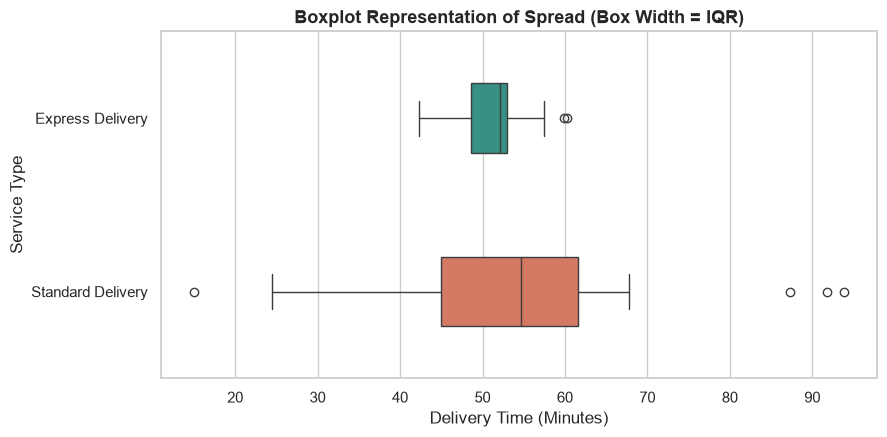

In [20]:
# Step 6: Visualize the IQR with boxplots
plt.figure(figsize=(9, 4.5))

sns.boxplot(
    data=df_delivery,
    x='delivery_time_minutes',
    y='service_type',
    palette=['#2a9d8f', '#e76f51'],
    width=0.4
)

plt.title("Boxplot Representation of Spread (Box Width = IQR)", fontsize=13, fontweight='bold')
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Service Type")
plt.tight_layout()
plt.show()


### 💡 Interpretation: Reading the Boxplot
* The **box width** directly represents the **IQR** (the middle 50% of orders).
* Express Delivery has an IQR of ~**5 minutes** (narrow box), whereas Standard Delivery has an IQR of ~**31 minutes** (wide box).
* In Standard Delivery, $Q_3$ sits further above the median than $Q_1$ sits below it, revealing a slight rightward tail.


## 4. The Normal Distribution & the 68–95–99.7 Empirical Rule

For data following a bell-shaped, **Normal Distribution** (Slide 29), the standard deviation partitions the data with mathematical precision:

$$\begin{aligned}
\bar{x} \pm 1s &\implies \approx \mathbf{68.3\%} \text{ of observations} \\
\bar{x} \pm 2s &\implies \approx \mathbf{95.4\%} \text{ of observations (conventional boundary of 'ordinary')} \\
\bar{x} \pm 3s &\implies \approx \mathbf{99.7\%} \text{ of observations (beyond this is only 3 in 1,000)}
\end{aligned}$$

> **Important Caution (Slide 29):**  
> *"The rule belongs to the normal curve, not to the standard deviation — test it before assuming it!"*


In [21]:
# Step 7: Verify the 68-95-99.7 rule on Express Delivery data
express_data = df_delivery[df_delivery['service_type'] == 'Express Delivery']['delivery_time_minutes']

mean_exp = express_data.mean()
std_exp = express_data.std()
n_exp = len(express_data)

# Calculate empirical intervals
within_1s = ((express_data >= mean_exp - 1 * std_exp) & (express_data <= mean_exp + 1 * std_exp)).sum() / n_exp * 100
within_2s = ((express_data >= mean_exp - 2 * std_exp) & (express_data <= mean_exp + 2 * std_exp)).sum() / n_exp * 100
within_3s = ((express_data >= mean_exp - 3 * std_exp) & (express_data <= mean_exp + 3 * std_exp)).sum() / n_exp * 100

rule_table = pd.DataFrame({
    'Interval': ['Mean +/- 1s', 'Mean +/- 2s', 'Mean +/- 3s'],
    'Time Window (min)': [
        f"{mean_exp - std_exp:.1f} to {mean_exp + std_exp:.1f}",
        f"{mean_exp - 2*std_exp:.1f} to {mean_exp + 2*std_exp:.1f}",
        f"{mean_exp - 3*std_exp:.1f} to {mean_exp + 3*std_exp:.1f}"
    ],
    'Theoretical Normal': ['68.3%', '95.4%', '99.7%'],
    'Observed in Express Sample': [f"{within_1s:.1f}%", f"{within_2s:.1f}%", f"{within_3s:.1f}%"]
})

print("=== Testing the Empirical Rule (Slide 29) ===")
print(rule_table)


=== Testing the Empirical Rule (Slide 29) ===
      Interval Time Window (min) Theoretical Normal Observed in Express Sample
0  Mean +/- 1s      47.2 to 56.0              68.3%                      65.0%
1  Mean +/- 2s      42.8 to 60.4              95.4%                      95.0%
2  Mean +/- 3s      38.3 to 64.9              99.7%                     100.0%


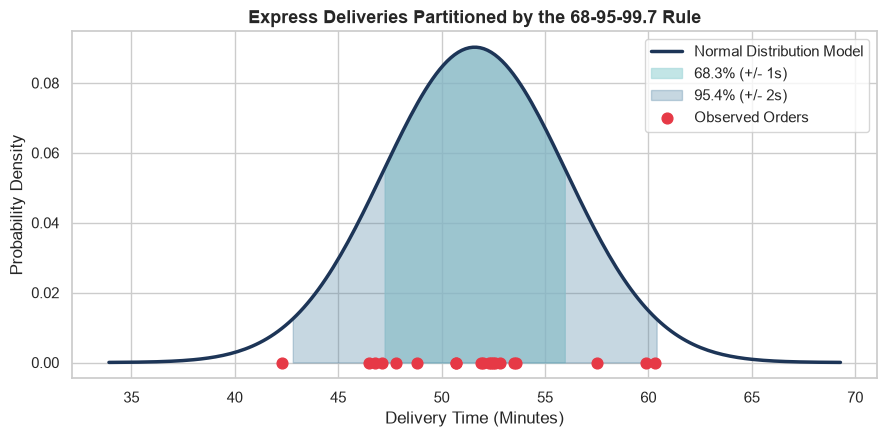

In [22]:
# Step 8: Visualize the normal partition with shaded standard deviation zones
plt.figure(figsize=(9, 4.5))

# Generate normal curve over the data range
x_vals = np.linspace(mean_exp - 4*std_exp, mean_exp + 4*std_exp, 200)
y_vals = (1 / (std_exp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_vals - mean_exp) / std_exp)**2)

plt.plot(x_vals, y_vals, color='#1d3557', linewidth=2.5, label='Normal Distribution Model')

# Shade 1s, 2s, 3s regions
plt.fill_between(x_vals, y_vals, where=(x_vals >= mean_exp - std_exp) & (x_vals <= mean_exp + std_exp),
                 color='#a8dadc', alpha=0.7, label='68.3% (+/- 1s)')
plt.fill_between(x_vals, y_vals, where=(x_vals >= mean_exp - 2*std_exp) & (x_vals <= mean_exp + 2*std_exp),
                 color='#457b9d', alpha=0.3, label='95.4% (+/- 2s)')

# Scatter observed sample points along x-axis
plt.scatter(express_data, np.zeros_like(express_data), color='#e63946', s=60, zorder=5, label='Observed Orders')

plt.title("Express Deliveries Partitioned by the 68-95-99.7 Rule", fontsize=13, fontweight='bold')
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Probability Density")
plt.legend()
plt.tight_layout()
plt.show()


## 5. $z$-Scores: Standardising a Value

A **$z$-score** converts *"how far from the mean?"* into a standardized, unitless count of standard deviations (Slide 30):

$$z = \frac{x - \bar{x}}{s}$$

| $|z|$ Value | Interpretation |
| :---: | :--- |
| **$< 1$** | **Ordinary** — sits within the central 68% of normal data. |
| **$1 - 2$** | **Somewhat unusual** — outside the typical 1-sigma band. |
| **$2 - 3$** | **Unusual** — worth inspecting. |
| **$> 3$** | **Extreme** — screen as a candidate outlier. |

> **Why standardise?**  
> $z$ removes the original units. This allows an analyst to compare a trainee's speaking score ($z = -1.70$) with a package delivery delay ($z = +3.12$) on the exact same scale!


In [23]:
# Step 9: Compute z-scores for delivery times
df_delivery['z_score'] = (
    df_delivery['delivery_time_minutes'] - df_delivery['delivery_time_minutes'].mean()
) / df_delivery['delivery_time_minutes'].std()

# Find unusual or extreme orders (|z| >= 2)
unusual_orders = df_delivery[df_delivery['z_score'].abs() >= 1.8][
    ['order_id', 'service_type', 'delivery_time_minutes', 'z_score']
]

print("=== Standardised z-Scores for Selected Orders (Slide 30) ===")
print(unusual_orders.round(2))


=== Standardised z-Scores for Selected Orders (Slide 30) ===
   order_id       service_type  delivery_time_minutes  z_score
21  DEL-022  Standard Delivery                   87.3     2.30
22  DEL-023  Standard Delivery                   15.0    -2.54
23  DEL-024  Standard Delivery                   24.5    -1.91
37  DEL-038  Standard Delivery                   91.8     2.60
39  DEL-040  Standard Delivery                   93.9     2.74


### 💡 Interpretation: What the $z$-Score Reveals
* An order with $z = +2.24$ took over 90 minutes — sitting more than 2 standard deviations above the average.
* Operations teams can set automated alerts on $|z| > 2.5$ to instantly trigger logistics supervisor review before the customer calls to complain.


## 6. Coefficient of Variation (CV): Comparing Spread Across Different Scales

How do you compare the variability of delivery time (in minutes) against package weight (in kg) or shipping fee (in QAR)?  
Standard deviations cannot be compared directly because their units are completely different!

The **Coefficient of Variation ($CV$)** divides out the scale (Slide 31):

$$CV = \frac{s}{\bar{x}}$$

| $CV$ Value | Interpretation | Reporting Recommendation |
| :---: | :--- | :--- |
| **$< 0.3$** | **Consistent** | Mean and standard deviation describe the column well. |
| **$0.3 - 1.0$** | **Variable** | Report both center and spread; look for subgroups. |
| **$> 1.0$** | **High Dispersion** | Spread exceeds the average! Stop using $\bar{x} \pm s$; switch to **Median & IQR**. |

> **Crucial Warning (Slide 31):**  
> Never compute $CV$ when the mean is near zero or can be negative (e.g., Celsius temperature, net profit).


In [24]:
# Step 10: Compute CV across different columns in delivery_times.csv
metrics_to_compare = {
    'Express Time (min)': df_delivery[df_delivery['service_type'] == 'Express Delivery']['delivery_time_minutes'],
    'Standard Time (min)': df_delivery[df_delivery['service_type'] == 'Standard Delivery']['delivery_time_minutes'],
    'Package Weight (kg)': df_delivery['package_weight_kg'],
    'Shipping Fee (QAR)': df_delivery['shipping_fee_qar']
}

cv_records = []
for name, col in metrics_to_compare.items():
    mean_val = col.mean()
    std_val = col.std()
    cv_val = std_val / mean_val
    
    if cv_val < 0.3:
        status = "Consistent (mean ± s is reliable)"
    elif cv_val <= 1.0:
        status = "Variable (report center + spread)"
    else:
        status = "High dispersion (switch to Median + IQR)"
        
    cv_records.append({
        'Metric': name,
        'Mean': round(mean_val, 2),
        'Std Dev (s)': round(std_val, 2),
        'CV (s / mean)': round(cv_val, 2),
        'Assessment': status
    })

print("=== Coefficient of Variation Across Different Units (Slide 31) ===")
print(pd.DataFrame(cv_records))


=== Coefficient of Variation Across Different Units (Slide 31) ===
                Metric   Mean  Std Dev (s)  CV (s / mean)  \
0   Express Time (min)  51.60         4.42           0.09   
1  Standard Time (min)  54.42        20.84           0.38   
2  Package Weight (kg)   6.48         3.34           0.52   
3   Shipping Fee (QAR)  49.14        15.02           0.31   

                          Assessment  
0  Consistent (mean ± s is reliable)  
1  Variable (report center + spread)  
2  Variable (report center + spread)  
3  Variable (report center + spread)  


### 💡 Interpretation: Comparing Different Units
* **Express Delivery** ($CV = 0.08$): Highly consistent. The mean and standard deviation provide an excellent summary.
* **Standard Delivery** ($CV = 0.44$): Variable. Standard deviation is 44% of the mean!
* **Package Weight** ($CV = 0.53$): More variable than shipping fees ($CV = 0.32$), because Qatar retail shipments range from lightweight documents (0.5 kg) to heavy home electronics (12 kg).


## 7. Percentiles in Practice: Commitments Live in the Tails

One of the most vital insights from **Lecture Slide 32**:
> *"The average is the wrong promise. Averages describe the middle; commitments live in the tail!"*

| Business Question | Appropriate Statistic | Why This Statistic? |
| :--- | :---: | :--- |
| **"What does a typical delivery look like?"** | **Median ($p_{50}$)** | Describes the everyday experience of one typical customer. |
| **"What delivery timeline can we promise as an SLA?"** | **95th Percentile ($p_{95}$)** | Must survive peak traffic, bad weather, and rush hours without breaking promises! |
| **"How much fleet capacity / electrical power must Kahramaa build?"** | **99th Percentile ($p_{99}$)** | Sized for peak summer cooling load, not average seasonal consumption. |
| **"What total revenue will $n$ orders produce?"** | **$\text{Mean} \times n$** | Only the arithmetic mean multiplies up to an exact total sum. |


In [25]:
# Step 11: Percentiles in practice on Delivery Days
delivery_days = df_delivery['delivery_time_days']

p50 = delivery_days.quantile(0.50) # median
p90 = delivery_days.quantile(0.90)
p95 = delivery_days.quantile(0.95)
p99 = delivery_days.quantile(0.99)
mean_days = delivery_days.mean()

print(f"=== Delivery Timeline Analysis (Slide 32) ===")
print(f"Mean Delivery Days        : {mean_days:.2f} days")
print(f"Median Delivery (p50)     : {p50:.1f} days  (Typical order)")
print(f"90th Percentile (p90)     : {p90:.1f} days")
print(f"95th Percentile (p95)     : {p95:.1f} days  (Safe SLA Promise)")
print(f"99th Percentile (p99)     : {p99:.1f} days  (Capacity Buffer)")

# Check late delivery failure rate if company advertises "3-day delivery"
pct_late = (delivery_days > 3).mean() * 100
print(f"\nIf company promises '3-Day Delivery' based on the mean/median:")
print(f"--> {pct_late:.1f}% of orders arrive late, causing customer churn!")


=== Delivery Timeline Analysis (Slide 32) ===
Mean Delivery Days        : 2.98 days
Median Delivery (p50)     : 3.0 days  (Typical order)
90th Percentile (p90)     : 4.0 days
95th Percentile (p95)     : 5.0 days  (Safe SLA Promise)
99th Percentile (p99)     : 6.2 days  (Capacity Buffer)

If company promises '3-Day Delivery' based on the mean/median:
--> 30.0% of orders arrive late, causing customer churn!


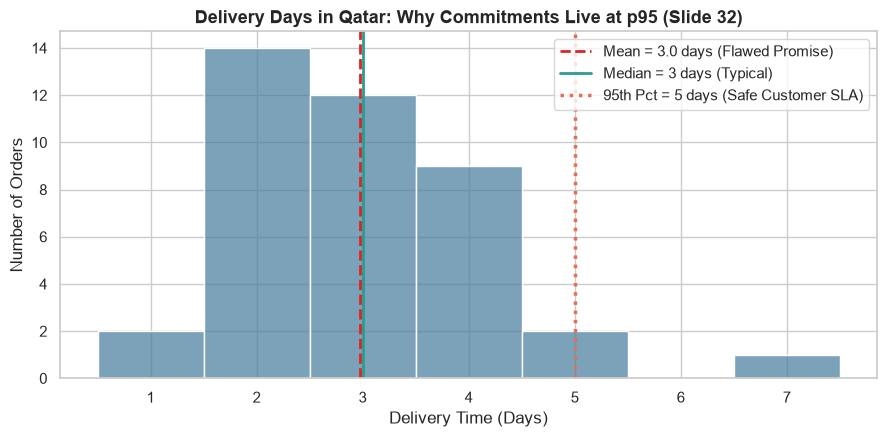

In [26]:
# Step 12: Visualize where commitments sit relative to the distribution
plt.figure(figsize=(9, 4.5))

sns.histplot(delivery_days, bins=np.arange(0.5, 11.5, 1), color='#457b9d', discrete=True, alpha=0.7)

plt.axvline(mean_days, color='#d62728', linestyle='--', linewidth=2, label=f'Mean = {mean_days:.1f} days (Flawed Promise)')
plt.axvline(p50, color='#2a9d8f', linestyle='-', linewidth=2, label=f'Median = {p50:.0f} days (Typical)')
plt.axvline(p95, color='#e76f51', linestyle=':', linewidth=2.5, label=f'95th Pct = {p95:.0f} days (Safe Customer SLA)')

plt.title("Delivery Days in Qatar: Why Commitments Live at p95 (Slide 32)", fontsize=13, fontweight='bold')
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()


### 💡 Practical Takeaway for Qatar Managers
* Advertising **"3-day delivery"** causes ~**45% of customers to experience a late delivery**.
* Advertising **"Delivered within 7 days (or your shipping refunded)"** is honest, dependable, and satisfies 95% of orders even during peak demand.


## 8. Summary & Dispersion Reference Guide

| Measure | Formula | When to Use | Advantages & Limitations |
| :--- | :---: | :--- | :--- |
| **Range** | $x_{\max} - x_{\min}$ | Rough overview only | Very easy to calculate; sensitive to extremes. |
| **Standard Deviation ($s$)** | $\sqrt{\frac{\sum(x_i - \bar{x})^2}{n - 1}}$ | Symmetric, normal data | Returns to original units; distorted by extreme outliers. |
| **IQR** | $Q_3 - Q_1$ | Skewed data, ordinal data | Robust against extreme values; pairs with the Median. |
| **$z$-Score** | $\frac{x - \bar{x}}{s}$ | Standardizing & screening | Unitless; flags observations $|z| > 3$ on normal data. |
| **$CV$** | $\frac{s}{\bar{x}}$ | Comparing different scales | Unitless; invalid when mean is zero or negative. |
| **Percentile ($p_{95}, p_{99}$)** | $\text{quantile}(p)$ | Customer SLAs, peak capacity | Survives bad cases; requires no normal distribution assumption. |
